# Audio Track — Phase 2

**Goal:** Raw recording → Demucs → BasicPitch → tempo/rhythm → fingering → GP5 export.

**Best-quality tabs:** Sections 3–6 use the tuned `PipelineConfig` from `data/eval/test1_best/best_combined.json` and the same `run_audio_stage` / `run_fingering_stage` / export path as the eval pipeline (librosa onset snap, adaptive rhythm, Viterbi fingering, `_resolve_meter` time-signature/tempo-map estimation, and `duration_mode="note_value"` with grid-phase de-bias + leading-onset gap correction).

Set **capo** and **tuning** in §3a when the recording is not standard EADGBE.

**Run top to bottom** when you add a new recording.

Stages:
1. Load + visualize audio
2. Demucs guitar separation
3. BasicPitch + capo/tuning setup
4. Librosa onset visualization + `run_audio_stage` filtering
5. Viterbi fingering
6. GP5 export


## 0. Environment check

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

print('librosa:', librosa.__version__)
print('numpy:', np.__version__)
print('ready')


librosa: 0.11.0
numpy: 2.4.5
ready


## 1. Load and visualize the raw audio

Change `AUDIO_PATH` to point to your recording. The file should be in `../audio_recording/`.

**What you're looking for in the waveform:**
- Clear note attacks (sharp transients) → good onset detection
- Minimal background noise between notes
- No clipping (waveform should stay within ±1.0)

/Users/c1prk/aitabs/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Duration:      265.51 seconds
Sample rate:   22050 Hz
Total samples: 5854599
Peak amplitude: 0.912  (>0.99 means clipping)


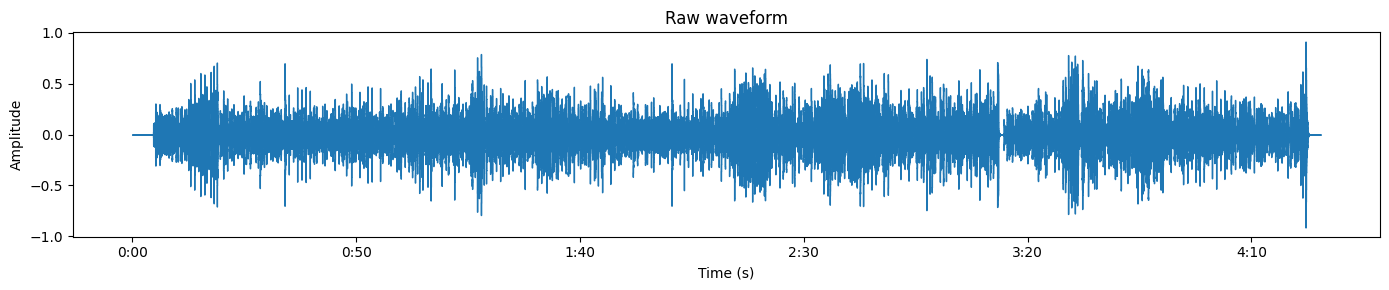

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

AUDIO_PATH = '../audio_recording/test_audio_6.mp3'
AUDIO_PATH = Path(AUDIO_PATH).expanduser()
CLIP_OFFSET = 0
CLIP_DURATION = 10

y, sr = librosa.load(str(AUDIO_PATH), sr=22050)

print(f'Duration:      {librosa.get_duration(y=y, sr=sr):.2f} seconds')
print(f'Sample rate:   {sr} Hz')
print(f'Total samples: {len(y)}')
print(f'Peak amplitude: {np.abs(y).max():.3f}  (>0.99 means clipping)')

plt.figure(figsize=(14, 3))
librosa.display.waveshow(y, sr=sr)
plt.title('Raw waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

## 2. Demucs source separation

**What Demucs does:** The htdemucs model was trained on thousands of songs to separate audio into stems (drums, bass, vocals, other). Guitar lives in 'other'. With `--two-stems other` it only produces two files:
- `other.wav`     ← guitar goes here
- `no_other.wav`  ← everything else

**torchcodec fix:** If you see `ImportError: TorchCodec is required`, run:
```
pip install torchcodec
```
This is a new torchaudio dependency as of v2.1 that isn't always installed automatically.

**Solo guitar recordings:** If your recording is already solo guitar with no backing, Demucs still helps — it removes room noise and string buzz that isn't part of the note.

In [3]:
import subprocess
import sys
import os
from pathlib import Path
import soundfile as sf
OUTPUT_DIR = '../audio_recording/demucs_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)
CLIP_OFFSET = 5
CLIP_DURATION = 10
y_clip, sr_clip = librosa.load(
    str(AUDIO_PATH),
    sr=22050
)

clip_dir = Path(OUTPUT_DIR) / 'clips'
clip_dir.mkdir(parents=True, exist_ok=True)
clip_path = clip_dir / f'{Path(AUDIO_PATH).stem}_offset{int(CLIP_OFFSET)}s_{int(CLIP_DURATION)}s.wav'
sf.write(str(clip_path), y_clip, sr_clip)
print(f'Demucs input clip: {clip_path.resolve()}')

result = subprocess.run([
    sys.executable, '-m', 'demucs',
    '--two-stems', 'other',
    '-o', OUTPUT_DIR,
    str(clip_path),
], capture_output=True, text=True)

print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)
    raise RuntimeError('Demucs failed — see stderr above')
else:
    print('Demucs finished successfully')

# Build the expected output path (Demucs writes under htdemucs/, not htdemucs_2stems/)
track_name = clip_path.stem
GUITAR_PATH = Path(OUTPUT_DIR) / 'htdemucs' / track_name / 'other.wav'
print(f'Guitar stem: {GUITAR_PATH}')
print(f'Exists: {GUITAR_PATH.exists()}')

Demucs input clip: /Users/c1prk/aitabs-pipeline/audio_recording/demucs_output/clips/test_audio_6_offset5s_10s.wav
Important: the default model was recently changed to `htdemucs` the latest Hybrid Transformer Demucs model. In some cases, this model can actually perform worse than previous models. To get back the old default model use `-n mdx_extra_q`.
Selected model is a bag of 1 models. You will see that many progress bars per track.
Separated tracks will be stored in /Users/c1prk/aitabs-pipeline/audio_recording/demucs_output/htdemucs
Separating track ../audio_recording/demucs_output/clips/test_audio_6_offset5s_10s.wav

Demucs finished successfully
Guitar stem: ../audio_recording/demucs_output/htdemucs/test_audio_6_offset5s_10s/other.wav
Exists: True


### 2b. Compare original vs separated waveforms

Listen for: the separated file should sound like just the guitar with less reverb/noise. It won't be perfect — Demucs introduces some artifacts (a slight watery sound) but pitch information is preserved.

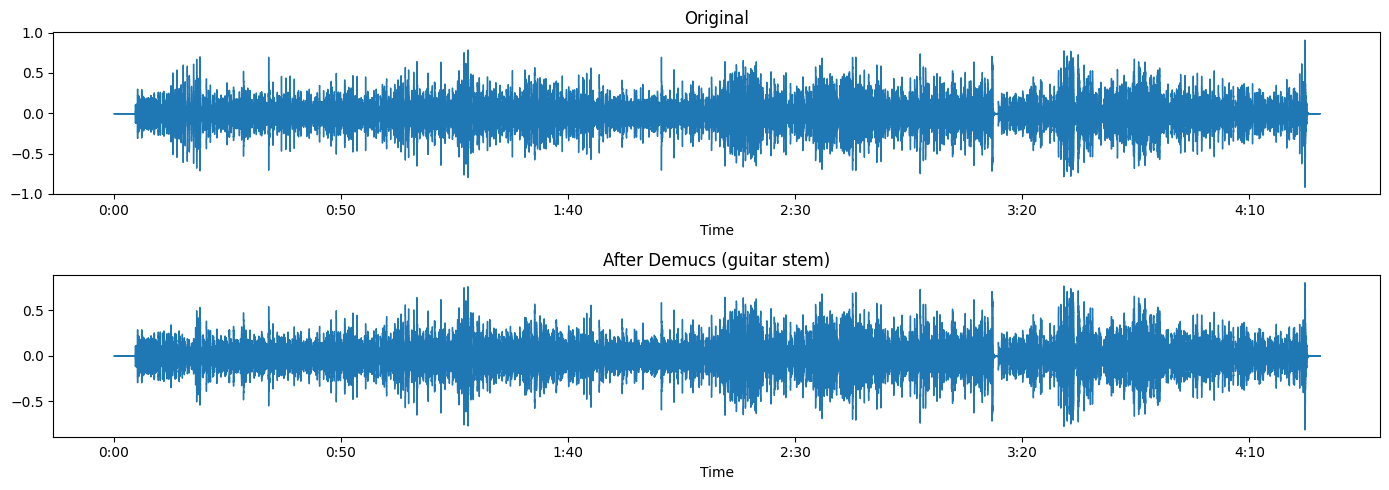

Original duration:  265.51s
Separated duration: 265.51s


In [4]:
from pathlib import Path

# Resolve from disk (Demucs writes htdemucs/<track>/other.wav); do not rely on a stale GUITAR_PATH
OUTPUT_DIR = Path('../audio_recording/demucs_output')
track_name = f'{Path(AUDIO_PATH).stem}_offset{int(CLIP_OFFSET)}s_{int(CLIP_DURATION)}s'
GUITAR_PATH = Path(OUTPUT_DIR) / 'htdemucs' / track_name / 'other.wav'

if not GUITAR_PATH.exists():
    raise FileNotFoundError(
        f'Guitar stem not found: {GUITAR_PATH.resolve()}\n'
        'Run the Demucs cell above successfully before continuing.'
    )

y_guitar, sr_guitar = librosa.load(str(GUITAR_PATH), sr=22050)

fig, axes = plt.subplots(2, 1, figsize=(14, 5))

librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title('Original')

librosa.display.waveshow(y_guitar, sr=sr_guitar, ax=axes[1])
axes[1].set_title('After Demucs (guitar stem)')

plt.tight_layout()
plt.show()

print(f'Original duration:  {librosa.get_duration(y=y, sr=sr):.2f}s')
print(f'Separated duration: {librosa.get_duration(y=y_guitar, sr=sr_guitar):.2f}s')

## 3. BasicPitch note detection

Uses `aitabs.pipeline.audio.basic_pitch_infer.predict_notes` (filters CoreML debug spam) with thresholds from **`PIPELINE_CFG`** — the tuned config from `data/eval/test1_best/best_combined.json`.


In [5]:
import sys
sys.path.insert(0, '..')

from pathlib import Path

import librosa
import numpy as np
import soundfile as sf
from basic_pitch import ICASSP_2022_MODEL_PATH

import importlib
import aitabs.eval.config as _config_mod
importlib.reload(_config_mod)  # pick up new config fields without a kernel restart
from aitabs.eval.config import PipelineConfig
from aitabs.pipeline.audio.basic_pitch_infer import predict_notes

REPO_ROOT = Path('..').resolve()

# Tuned pipeline config (best knobs from eval search)
_cfg_path = REPO_ROOT / 'data/eval/test1_best/best_combined.json'
PIPELINE_CFG = PipelineConfig.load_json(_cfg_path)
if PIPELINE_CFG.fingering_config_path:
    fp = Path(PIPELINE_CFG.fingering_config_path)
    if not fp.is_file():
        PIPELINE_CFG.fingering_config_path = str((REPO_ROOT / fp).resolve())

# Peak-normalize stem so BasicPitch sees consistent level
if 'GUITAR_PATH' not in globals():
    OUTPUT_DIR = Path('../audio_recording/demucs_output')
    track_name = f'{Path(AUDIO_PATH).stem}_offset{int(CLIP_OFFSET)}s_{int(CLIP_DURATION)}s'
    GUITAR_PATH = OUTPUT_DIR / 'htdemucs' / track_name / 'other.wav'

y_stem, sr_stem = librosa.load(str(GUITAR_PATH), sr=22050)
peak = float(np.max(np.abs(y_stem)))
y_norm = y_stem / peak if peak > 0 else y_stem.copy()

NORMALIZED_GUITAR_PATH = Path(GUITAR_PATH).with_name(f'{Path(GUITAR_PATH).stem}_normalized.wav')
sf.write(str(NORMALIZED_GUITAR_PATH), y_norm, sr_stem)
print(f'Stem peak before normalize: {peak:.4f}')
print(f'BasicPitch input: {NORMALIZED_GUITAR_PATH.resolve()}')
print(f'Config: confidence={PIPELINE_CFG.confidence_threshold}, onset={PIPELINE_CFG.onset_threshold}')

_model_output, _midi_data, note_events = predict_notes(
    str(NORMALIZED_GUITAR_PATH),
    ICASSP_2022_MODEL_PATH,
    onset_threshold=PIPELINE_CFG.onset_threshold,
    frame_threshold=PIPELINE_CFG.frame_threshold,
    minimum_note_length=PIPELINE_CFG.minimum_note_length_ms,
    minimum_frequency=PIPELINE_CFG.minimum_frequency_hz,
    maximum_frequency=PIPELINE_CFG.maximum_frequency_hz,
    melodia_trick=PIPELINE_CFG.melodia_trick,
)

print(f'Detected {len(note_events)} note events')
print()
print(f'{"Note":>5}  {"Start":>6}  {"End":>6}  {"Conf":>5}')
print('-' * 30)
for start, end, pitch, confidence, _bend in note_events[:20]:
    note_name = librosa.midi_to_note(int(pitch))
    print(f'{note_name:>5}  {start:>6.2f}s  {end:>6.2f}s  {confidence:>5.2f}')
if len(note_events) > 20:
    print(f'  ... and {len(note_events) - 20} more')


scikit-learn version 1.8.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
/Users/c1prk/aitabs/venv/lib/python3.11/site-packages/resampy/filters.py:50: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Torch version 2.12.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.


Stem peak before normalize: 0.8115
BasicPitch input: /Users/c1prk/aitabs-pipeline/audio_recording/demucs_output/htdemucs/test_audio_6_offset5s_10s/other_normalized.wav
Config: confidence=0.52, onset=0.65
Detected 2180 note events

 Note   Start     End   Conf
------------------------------
  C♯4  262.42s  262.50s   0.54
   D4  262.11s  262.37s   0.36
   G3  262.11s  262.37s   0.54
   F4  261.75s  261.85s   0.56
   D5  261.74s  261.88s   0.61
  A♯4  261.29s  261.37s   0.46
   A4  261.18s  261.29s   0.58
   G4  261.07s  261.16s   0.55
   F4  260.95s  261.08s   0.61
   E4  260.81s  260.92s   0.51
   D4  260.68s  260.93s   0.59
   A2  260.24s  260.42s   0.63
   E4  260.23s  260.36s   0.49
  C♯4  260.23s  260.37s   0.54
   G3  259.77s  260.15s   0.49
   A2  259.55s  260.24s   0.56
  C♯4  259.53s  260.23s   0.58
   D4  259.30s  259.51s   0.67
   F4  258.94s  259.26s   0.58
   G4  258.65s  259.42s   0.55
  ... and 2160 more


### 3a. Capo and tuning

Set the **written tab** context: capo fret and open-string tuning (low E → high e). BasicPitch still hears concert pitch; fingering and GP5 export map notes onto your capo/tuning.

Presets: `'standard'`, `'half_step_down'`, `'drop_d'`. Or pass six note names (e.g. `['Eb2', 'Ab2', 'Db3', 'Gb3', 'Bb3', 'Eb4']`) or MIDI integers.


In [6]:
from aitabs.pipeline.mapping.guitar import GuitarSetup, STANDARD_TUNING

# --- Guitar setup (edit these) ---
CAPO_FRET = 3
TUNING = 'standard'  # preset name, or list of 6 note names / MIDI ints

_TUNING_PRESETS = {
    'standard': STANDARD_TUNING,
    'half_step_down': [39, 44, 49, 54, 58, 63],
    'drop_d': [38, 45, 50, 55, 59, 64],
}


def build_guitar_setup(capo: int, tuning) -> GuitarSetup:
    if isinstance(tuning, str):
        key = tuning.lower().replace('-', '_').replace(' ', '_')
        if key not in _TUNING_PRESETS:
            raise ValueError(
                f'Unknown TUNING preset {tuning!r}. '
                f'Choose from {sorted(_TUNING_PRESETS)} or pass a 6-item list.'
            )
        midi = _TUNING_PRESETS[key]
    elif tuning and isinstance(tuning[0], str):
        midi = [librosa.note_to_midi(n) for n in tuning]
    else:
        midi = list(tuning)
    if len(midi) != 6:
        raise ValueError(f'TUNING must have 6 strings, got {len(midi)}')
    return GuitarSetup(tuning=tuple(midi), capo=int(capo))


guitar_setup = build_guitar_setup(CAPO_FRET, TUNING)
STRING_NAMES = [librosa.midi_to_note(m) for m in guitar_setup.tuning]
print(f'Capo: fret {guitar_setup.capo}')
print(f'Tuning (written open strings): {STRING_NAMES}')
if not guitar_setup.is_standard():
    print(f'Effective open strings @ capo: {[librosa.midi_to_note(m) for m in guitar_setup.effective_tuning()]}')


Capo: fret 3
Tuning (written open strings): ['E2', 'A2', 'D3', 'G3', 'B3', 'E4']
Effective open strings @ capo: ['G2', 'C3', 'F3', 'A♯3', 'D4', 'G4']


### 3b. Confidence histogram

Use this to choose your `confidence_threshold`. The distribution is usually bimodal: a cluster near 0.3–0.5 (noise/harmonics) and a cluster near 0.8–1.0 (real notes). Your threshold should sit in the valley between those clusters.

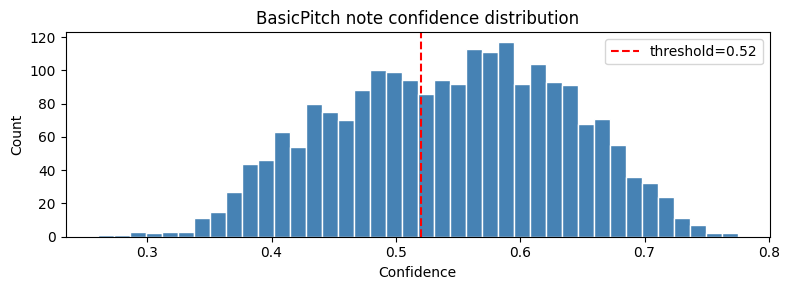

1288/2180 notes above threshold 0.52


In [7]:
confidences = [ev[3] for ev in note_events]
threshold = PIPELINE_CFG.confidence_threshold

plt.figure(figsize=(8, 3))
plt.hist(confidences, bins=40, color='steelblue', edgecolor='white')
plt.axvline(threshold, color='red', linestyle='--', label=f'threshold={threshold}')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.title('BasicPitch note confidence distribution')
plt.legend()
plt.tight_layout()
plt.show()

above = sum(1 for c in confidences if c >= threshold)
print(f'{above}/{len(confidences)} notes above threshold {threshold}')


### 3c. BPM / beat grid

Preview tempo estimate from the normalized stem. The final beat grid used for tab timing comes from `run_audio_stage` in §4b (after librosa onset snap).


Preview BPM: 129.2  (confidence 0.96)
Beat period: 0.464s  |  16th = 0.116s


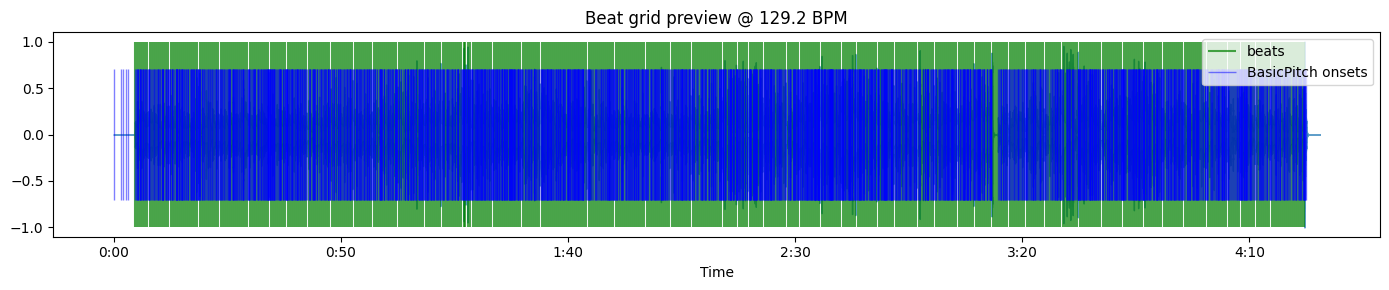

In [8]:
from aitabs.pipeline.audio.tempo import estimate_tempo

preview_tempo = estimate_tempo(
    y=y_norm,
    sr=sr_stem,
    hop_length=PIPELINE_CFG.tempo_hop_length,
    ticks_per_beat=PIPELINE_CFG.ticks_per_beat,
)

print(f'Preview BPM: {preview_tempo.bpm:.1f}  (confidence {preview_tempo.confidence:.2f})')
print(f'Beat period: {preview_tempo.beat_period:.3f}s  |  16th = {preview_tempo.tick_duration:.3f}s')

fig, ax = plt.subplots(figsize=(14, 3))
librosa.display.waveshow(y_norm, sr=sr_stem, ax=ax, alpha=0.7)
ax.vlines(preview_tempo.beat_times, -1, 1, color='green', alpha=0.7, linewidth=1.5, label='beats')
bp_times = [ev[0] for ev in note_events]
ax.vlines(bp_times, -0.7, 0.7, color='blue', alpha=0.5, linewidth=1, label='BasicPitch onsets')
ax.set_title(f'Beat grid preview @ {preview_tempo.bpm:.1f} BPM')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 4. Librosa onsets + audio-stage filtering

Section 4a visualizes librosa vs BasicPitch onsets. Section 4b applies the **same audio-stage chain as eval**: confidence filter → librosa snap → tempo dedup → adaptive rhythm quantization.


librosa detected 1123 onsets
BasicPitch detected 2180 notes


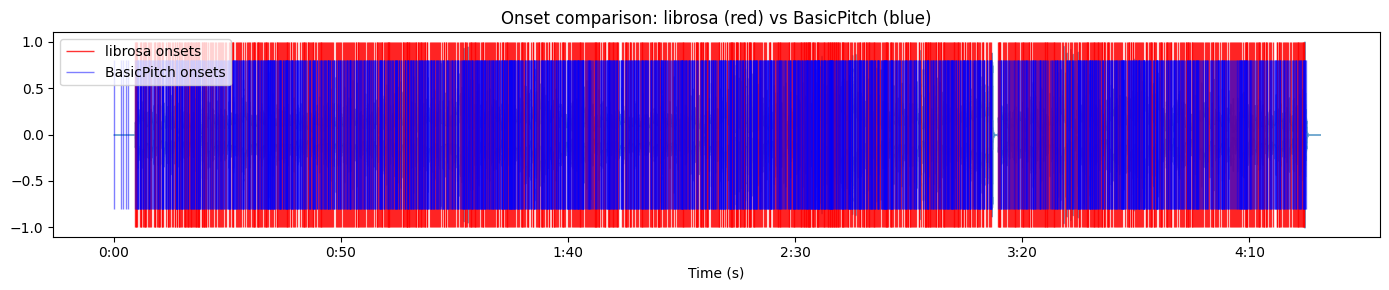

In [9]:
# 4a. Onset comparison (diagnostic)
from aitabs.pipeline.audio.onset import detect_onsets

onset_times = detect_onsets(
    str(NORMALIZED_GUITAR_PATH),
    delta=PIPELINE_CFG.librosa_onset_delta,
    hop_length=PIPELINE_CFG.tempo_hop_length,
)

print(f'librosa detected {len(onset_times)} onsets')
print(f'BasicPitch detected {len(note_events)} notes')

plt.figure(figsize=(14, 3))
librosa.display.waveshow(y_norm, sr=sr_stem, alpha=0.6)
plt.vlines(onset_times, -1, 1, color='red', alpha=0.8, linewidth=1, label='librosa onsets')
bp_times = [ev[0] for ev in note_events]
plt.vlines(bp_times, -0.8, 0.8, color='blue', alpha=0.5, linewidth=1, label='BasicPitch onsets')
plt.legend()
plt.title('Onset comparison: librosa (red) vs BasicPitch (blue)')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()


## 5. String/fret mapping

Uses `run_fingering_stage` (Viterbi DP) with capo/tuning from §3a when set.


In [10]:
# 4b. Audio-stage filtering — same code path as aitabs.eval.run.run_audio_stage
import importlib
import aitabs.eval.run as _run_mod
importlib.reload(_run_mod)
from aitabs.eval.run import run_audio_stage
from aitabs.pipeline.audio.tempo import annotate_notes_for_display
from aitabs.pipeline.mapping.guitar import midi_to_positions

_audio_input = clip_path if 'clip_path' in globals() else GUITAR_PATH
audio_stage = run_audio_stage(
    _audio_input,
    PIPELINE_CFG,
    stem_path=GUITAR_PATH,
)

filtered_notes = audio_stage.filtered_notes
tempo_analysis = audio_stage.tempo_analysis

print(f'{len(filtered_notes)} notes after audio stage @ {tempo_analysis.bpm:.1f} BPM')
if guitar_setup.capo or not guitar_setup.is_standard():
    print(f'Tab context: capo={guitar_setup.capo}, tuning={STRING_NAMES}')

annotated = annotate_notes_for_display(filtered_notes, tempo_analysis)
print(f'{"Note":>5}  {"Start":>6}  {"Beat":>4}  {"16th":>4}  Candidate positions')
print('-' * 72)
for row in annotated[:25]:
    note_name = librosa.midi_to_note(row['pitch_midi'])
    positions = midi_to_positions(row['pitch_midi'], setup=guitar_setup)
    pos_str = ', '.join(f'{STRING_NAMES[s]}:{f}' for s, f in positions)
    print(f'{note_name:>5}  {row["start"]:>6.2f}s  {row["beat"]:>4}  {row["subdivision"]:>4}  {pos_str}')
if len(annotated) > 25:
    print(f'  ... and {len(annotated) - 25} more')


1202 notes after audio stage @ 129.2 BPM
Tab context: capo=3, tuning=['E2', 'A2', 'D3', 'G3', 'B3', 'E4']
 Note   Start  Beat  16th  Candidate positions
------------------------------------------------------------------------
   G4    4.16s    -2    12  A2:19, D3:14, G3:9, B3:5, E4:0
  A♯4    4.83s     1     1  A2:22, D3:17, G3:12, B3:8, E4:3
  G♯2    5.11s     1    13  E2:1
   C4    5.41s     2     6  E2:17, A2:12, D3:7, G3:2
  G♯4    5.46s     2     8  A2:20, D3:15, G3:10, B3:6, E4:1
   G4    5.80s     3     3  A2:19, D3:14, G3:9, B3:5, E4:0
  A♯2    6.04s     3    13  E2:3
  D♯4    6.27s     4     3  E2:20, A2:15, D3:10, G3:5, B3:1
  A♯2    6.48s     4    12  E2:3
   C5    6.75s     5     4  D3:19, G3:14, B3:10, E4:5
  A♯4    6.94s     5    12  A2:22, D3:17, G3:12, B3:8, E4:3
   C5    7.18s     6     2  D3:19, G3:14, B3:10, E4:5
   F4    7.50s     6    16  E2:22, A2:17, D3:12, G3:7, B3:3
   C3    7.87s     7    12  E2:5, A2:0
  D♯4    7.87s     7    12  E2:20, A2:15, D3:10, G3:5, B3

In [11]:
import importlib
import aitabs.eval.run as _run_mod
importlib.reload(_run_mod)
from aitabs.eval.run import run_fingering_stage
from aitabs.pipeline.mapping.guitar import fret_to_midi

_gs = guitar_setup if (guitar_setup.capo or not guitar_setup.is_standard()) else None

tab_notes = run_fingering_stage(
    filtered_notes,
    tempo_analysis,
    PIPELINE_CFG,
    guitar_setup=_gs,
)

print(f'Mapped {len(tab_notes)} notes')
if _gs:
    print(f'Using capo={_gs.capo}, tuning={STRING_NAMES}')
print()
print(f'{"Note":>5}  {"Start":>6}  {"String":>6}  {"Fret":>4}  {"OK":>3}')
print('-' * 36)
for note in tab_notes[:30]:
    note_name = librosa.midi_to_note(note['pitch_midi'])
    ok = fret_to_midi(note['string'], note['fret'], setup=_gs) == note['pitch_midi']
    print(
        f'{note_name:>5}  {note["start"]:>6.2f}s  '
        f'{STRING_NAMES[note["string"]]:>6}  {note["fret"]:>4}  {"yes" if ok else "NO":>3}'
    )
if len(tab_notes) > 30:
    print(f'  ... and {len(tab_notes) - 30} more')


Mapped 1202 notes
Using capo=3, tuning=['E2', 'A2', 'D3', 'G3', 'B3', 'E4']

 Note   Start  String  Fret   OK
------------------------------------
   G4    4.16s      E4     0  yes
  A♯4    4.83s      E4     3  yes
  G♯2    5.11s      E2     1  yes
   C4    5.41s      G3     2  yes
  G♯4    5.46s      B3     6  yes
   G4    5.80s      B3     5  yes
  A♯2    6.04s      E2     3  yes
  D♯4    6.27s      G3     5  yes
  A♯2    6.48s      E2     3  yes
   C5    6.75s      E4     5  yes
  A♯4    6.94s      E4     3  yes
   C5    7.18s      E4     5  yes
   F4    7.50s      B3     3  yes
   C3    7.87s      A2     0  yes
  D♯4    7.87s      B3     1  yes
   C4    8.31s      G3     2  yes
  D♯4    8.55s      B3     1  yes
   F4    8.78s      B3     3  yes
   D4    9.13s      B3     0  yes
  G♯4    9.45s      E4     1  yes
   G2    9.71s      E2     0  yes
   G2   10.14s      E2     0  yes
   C3   10.64s      E2     5  yes
  D♯5   10.64s      E4     8  yes
   D5   10.96s      E4     7  yes
  A

## 6. Export Guitar Pro (.gp5)

Uses tuned export defaults: **`duration_mode="note_value"`** (rest-aware IOI notation) and `trim_leading_silence=True`. Writes capo and tuning from §3a into the GP5 file.

Same export path as `aitabs.eval.run`: meter (time signature + pickup) and a variable tempo map are resolved from the audio via `_resolve_meter`. With **`auto_rhythm=True`** (default in this notebook), the notation engine infers legato vs rests, tempo-spacing correction, and per-beat eighth/sixteenth resolution from the onsets — no per-clip flags.

Knobs live in `PIPELINE_CFG` (`data/eval/test1_best/best_combined.json`).


In [12]:
import importlib
from pathlib import Path

import guitarpro
import aitabs.export.gp5_layout as _gp5_layout
import aitabs.export.rhythm_notation as _rhythm_mod
import aitabs.export.guitarpro as _guitarpro_mod

# Reload dependencies first (gp5_layout → rhythm_notation → guitarpro) so re-running
# this cell picks up engine changes without a full kernel restart.
importlib.reload(_gp5_layout)
importlib.reload(_rhythm_mod)
importlib.reload(_guitarpro_mod)
from aitabs.export.guitarpro import export_gp5

output_dir = Path('../audio_recording/output')
output_dir.mkdir(parents=True, exist_ok=True)
stem = Path(AUDIO_PATH).stem if 'AUDIO_PATH' in globals() else 'clip'
gp5_path = output_dir / f'{stem}_offset{int(CLIP_OFFSET)}s_{int(CLIP_DURATION)}s.gp5'
tempo_bpm = int(round(tempo_analysis.bpm))

snap = PIPELINE_CFG.snap_to_grid and not tempo_analysis.uses_adaptive_template
duration = PIPELINE_CFG.duration_mode
if tempo_analysis.uses_adaptive_template and duration in ('grid_unit', 'to_next_onset'):
    duration = 'note_value'

# Resolve meter exactly like the eval pipeline (aitabs.eval.run._resolve_meter):
# estimate time signature + pickup (lead-in) and a variable tempo map from the
# audio when no reference is available. The note_value notation engine then runs
# grid-phase de-bias + leading-onset gap correction on top of this beat space.
from aitabs.eval.run import _resolve_meter

time_signature, tempo_map, lead_in_beats = _resolve_meter(PIPELINE_CFG, None, audio_stage)
print(f'meter={time_signature[0]}/{time_signature[1]}, lead_in_beats={lead_in_beats}, '
      f'tempo_map={"variable" if tempo_map is not None else "constant"}')

# Rhythm notation: auto_rhythm infers legato/rests, tempo-spacing correction, and
# per-beat eighth/sixteenth resolution from the onsets — no per-clip flags needed.
# Set AUTO_RHYTHM = False for strict GP5-reference-style export (offset-faithful).
AUTO_RHYTHM = True

written = export_gp5(
    tab_notes,
    gp5_path,
    title=stem,
    tempo=tempo_bpm,
    time_signature=time_signature,
    tempo_grid=tempo_analysis,
    snap_to_grid=snap,
    chord_grid_ticks=PIPELINE_CFG.chord_grid_ticks,
    duration_mode=duration,
    trim_leading_silence=PIPELINE_CFG.trim_leading_silence,
    enable_triplets=PIPELINE_CFG.enable_triplets,
    tuning=list(guitar_setup.tuning),
    capo=guitar_setup.capo,
    tempo_map=tempo_map,
    lead_in_beats=lead_in_beats,
    auto_rhythm=AUTO_RHYTHM,
)

parsed = guitarpro.parse(str(written))
track = parsed.tracks[0]
total_notes = sum(len(b.notes) for m in track.measures for b in m.voices[0].beats)
print(
    f'Wrote {written.resolve()}  (tempo={tempo_bpm} BPM, capo={track.offset}, '
    f'measures={len(track.measures)}, tab_notes={len(tab_notes)}, gp_notes={total_notes})'
)
print(f'duration_mode={duration!r}')
print(f'tuning={[librosa.midi_to_note(m) for m in guitar_setup.tuning]}')


meter=4/4, lead_in_beats=3, tempo_map=variable
Wrote /Users/c1prk/aitabs-pipeline/audio_recording/output/test_audio_6_offset5s_10s.gp5  (tempo=129 BPM, capo=3, measures=141, tab_notes=1202, gp_notes=1389)
duration_mode='note_value'
tuning=['E2', 'A2', 'D3', 'G3', 'B3', 'E4']
